# Preprocessing QC and Neural Inputs Trial

This notebook experiments with the package preprocessing stage, final record-level QC, and `neural_inputs.npy` packaging. Keep pipeline logic in `aquinas_toolkit`; use this notebook only to run and inspect artifacts.

## Setup

In [13]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

repo_root = Path.cwd()
if not (repo_root / "aquinas_toolkit").exists():
    repo_root = next(path for path in Path.cwd().parents if (path / "aquinas_toolkit").exists())
sys.path.insert(0, str(repo_root))

from aquinas_toolkit.preprocessing import open_preprocess_store

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
repo_root

WindowsPath('c:/Users/murat/Documents/GitHub/EWSHM_Competition')

## Active Preprocessing Configuration

In [14]:
config_path = repo_root / "configs" / "default.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
pre_cfg = config["preprocessing"]

pd.DataFrame(
    [
        {"variable": "sampling_rate_hz", "value": pre_cfg.get("sampling_rate_hz")},
        {"variable": "sensor_selection.decks", "value": pre_cfg.get("sensor_selection", {}).get("decks")},
        {"variable": "strain.locations", "value": pre_cfg.get("strain", {}).get("locations")},
        {"variable": "strain.peak_window_half_samples", "value": pre_cfg.get("strain", {}).get("peak_window_half_samples")},
        {"variable": "acc.min_aligned_samples", "value": pre_cfg.get("acc", {}).get("min_aligned_samples")},
        {"variable": "acc.fft_padding", "value": pre_cfg.get("acc", {}).get("fft_padding")},
        {"variable": "qc.flat_range_tolerance", "value": pre_cfg.get("qc", {}).get("flat_range_tolerance")},
        {"variable": "qc.mad_warning_threshold", "value": pre_cfg.get("qc", {}).get("mad_warning_threshold")},
        {"variable": "qc.mad_severe_threshold", "value": pre_cfg.get("qc", {}).get("mad_severe_threshold")},
    ]
)

,variable,value
0,sampling_rate_hz,100.0
1,sensor_selection.decks,[OLD]
2,strain.locations,"[INF, SHE, SUP]"
3,strain.peak_window_half_samples,100
4,acc.min_aligned_samples,500
5,acc.fft_padding,None
6,qc.flat_range_tolerance,0.0
7,qc.mad_warning_threshold,3.5
8,qc.mad_severe_threshold,5.0


## Run Preprocessing

In [15]:
RUN_PIPELINE = False
RUN_NAME = "preprocessing-qc-neural-trial"

if RUN_PIPELINE:
    from aquinas_toolkit.cli.run import run as aquinas_run

    sys.argv = ["aquinas", "run", "preprocess", "--name", RUN_NAME, "--verbose"]
    aquinas_run()

## Load Latest Preprocess Run

In [16]:
RUN_ID = None
latest_path = repo_root / "results" / "latest.json"
if RUN_ID is None:
    latest = json.loads(latest_path.read_text(encoding="utf-8"))
    RUN_ID = latest["run_id"]

run_dir = repo_root / "results" / RUN_ID
preprocess_dir = run_dir / "stages" / "preprocess"
report_dir = preprocess_dir / "report"
qc_dir = preprocess_dir / "qc_outputs"

paths = {
    "run_dir": run_dir,
    "preprocess_dir": preprocess_dir,
    "neural_inputs": preprocess_dir / "neural_inputs.npy",
    "qc_report": qc_dir / "event_qc_report.csv",
}
paths

{'run_dir': WindowsPath('c:/Users/murat/Documents/GitHub/EWSHM_Competition/results/2026-05-12T15-47-36Z'),
 'preprocess_dir': WindowsPath('c:/Users/murat/Documents/GitHub/EWSHM_Competition/results/2026-05-12T15-47-36Z/stages/preprocess'),
 'neural_inputs': WindowsPath('c:/Users/murat/Documents/GitHub/EWSHM_Competition/results/2026-05-12T15-47-36Z/stages/preprocess/neural_inputs.npy'),
 'qc_report': WindowsPath('c:/Users/murat/Documents/GitHub/EWSHM_Competition/results/2026-05-12T15-47-36Z/stages/preprocess/qc_outputs/event_qc_report.csv')}

## Neural Tensor and Sensor Numbering

In [17]:
neural_inputs = np.load(preprocess_dir / "neural_inputs.npy")
sensor_map = pd.read_csv(report_dir / "sensor_map.csv")
input_slices = json.loads((report_dir / "input_slices.json").read_text(encoding="utf-8"))
sensor_ids = json.loads((report_dir / "sensor_ids.json").read_text(encoding="utf-8"))

print("neural_inputs shape:", neural_inputs.shape)
display(pd.DataFrame(input_slices).T)
display(sensor_map.loc[sensor_map["include_flag"].astype(bool)].sort_values("global_model_channel_index"))

neural_inputs shape: (1311, 7025)


,shape,start,stop
acc_z_frequency,"[578, 8]",2400,7024
strain,"[200, 12]",0,2400
temperature,[1],7024,7025


,sensor_name,sensor_type,deck,span,side,location,axis_or_type,source_sensor_order,model_channel_index,global_model_channel_index,model_channel_id,include_flag,notes
0,OLD_S1_DO_INF_STR,STR,OLD,S1,DO,INF,INF,25,0.0,0.0,STR00,True,NaN
5,OLD_S1_DO_SHE_STR,STR,OLD,S1,DO,SHE,SHE,30,1.0,1.0,STR01,True,NaN
6,OLD_S1_DO_SUP_STR,STR,OLD,S1,DO,SUP,SUP,31,2.0,2.0,STR02,True,NaN
7,OLD_S1_UP_INF_STR,STR,OLD,S1,UP,INF,INF,32,3.0,3.0,STR03,True,NaN
10,OLD_S1_UP_SHE_STR,STR,OLD,S1,UP,SHE,SHE,35,4.0,4.0,STR04,True,NaN
11,OLD_S1_UP_SUP_STR,STR,OLD,S1,UP,SUP,SUP,36,5.0,5.0,STR05,True,NaN
12,OLD_S2_DO_INF_STR,STR,OLD,S2,DO,INF,INF,37,6.0,6.0,STR06,True,NaN
17,OLD_S2_DO_SHE_STR,STR,OLD,S2,DO,SHE,SHE,42,7.0,7.0,STR07,True,NaN
18,OLD_S2_DO_SUP_STR,STR,OLD,S2,DO,SUP,SUP,43,8.0,8.0,STR08,True,NaN
19,OLD_S2_UP_INF_STR,STR,OLD,S2,UP,INF,INF,44,9.0,9.0,STR09,True,NaN


## QC Reports

In [18]:
event_qc = pd.read_csv(qc_dir / "event_qc_report.csv")
sensor_qc = pd.read_csv(qc_dir / "sensor_qc_report.csv")
discarded_events = pd.read_csv(qc_dir / "discarded_events.csv")
qc_summary = json.loads((qc_dir / "qc_summary.json").read_text(encoding="utf-8"))
neural_summary = json.loads((report_dir / "neural_input_summary.json").read_text(encoding="utf-8"))

event_qc["discard_reason_display"] = event_qc["discard_reason"].replace(
    {"missing_record": "not_available_for_global_event"}
)

coverage_rows = event_qc["discard_reason_display"].eq("not_available_for_global_event").sum()
true_failure_rows = qc_summary.get("true_qc_failure_records", 0)
coverage_overview = pd.Series(
    {
        "retained_preprocess_events_checked": neural_summary.get("total_retained_preprocess_events"),
        "complete_selected_sensor_coverage_events": neural_summary.get("complete_selected_sensor_coverage_events"),
        "events_excluded_incomplete_selected_sensor_coverage": neural_summary.get("events_excluded_incomplete_selected_sensor_coverage"),
        "packaged_neural_events": neural_summary.get("retained_events"),
        "coverage_missing_qc_rows": coverage_rows,
        "true_qc_failure_rows": true_failure_rows,
    },
    name="value",
)

display(coverage_overview)
display(pd.Series(qc_summary, name="value"))
display(event_qc["qc_status"].value_counts(dropna=False).rename_axis("qc_status").to_frame("records"))
display(sensor_qc.sort_values(["sensor_status", "true_failure_rate", "coverage_missing_rate", "warning_rate"], ascending=[True, False, False, False]).head(20))

retained_preprocess_events_checked                         NaN
complete_selected_sensor_coverage_events                   NaN
events_excluded_incomplete_selected_sensor_coverage        NaN
packaged_neural_events                                  1311.0
coverage_missing_qc_rows                               54684.0
true_qc_failure_rows                                       0.0
Name: value, dtype: float64

counts_by_discard_reason             {'missing_record': 54684, 'strain_window_out_of_bounds': 119}
counts_by_sensor_type       {'ACC_Z': 53448, 'INF_STR': 26724, 'SHE_STR': 26724, 'SUP_STR': 26724}
counts_by_set                                                     {'AQUINAS_SET1_2022_07': 133620}
discard_rate                                                                              0.410141
discarded_records                                                                            54803
kept_records                                                                                 72294
total_records                                                                               133620
warning_rate                                                                              0.048818
warning_records                                                                               6523
Name: value, dtype: object

,records
qc_status,
keep,72294
discard,54803
warning,6523


KeyError: 'true_failure_rate'

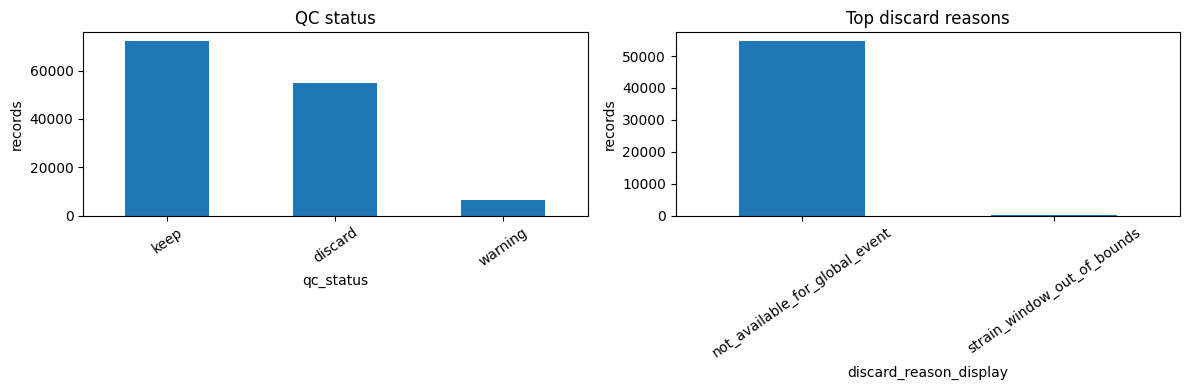

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
event_qc["qc_status"].value_counts().plot(kind="bar", ax=axes[0], title="QC status")
event_qc.loc[event_qc["discard_reason_display"].fillna("") != "", "discard_reason_display"].value_counts().head(10).plot(
    kind="bar", ax=axes[1], title="Top discard reasons"
)
for ax in axes:
    ax.set_ylabel("records")
    ax.tick_params(axis="x", labelrotation=35)
fig.tight_layout()

## Longest ACC-Z Records

These are the 50 longest ACC-Z sensor-record rows across the loaded QC dataset. `T_N` is the row-count-derived duration and is the primary sort key; `Duration` is kept beside it for comparison with TABLE metadata.

In [ ]:
acc_z_columns = [
    "set_id",
    "event_id",
    "sensor_name",
    "Start_Time",
    "End_Time",
    "Duration",
    "N",
    "T_N",
    "qc_status",
    "discard_reason",
    "warning_reason",
    "mad_score_max",
]

acc_z_qc = event_qc.loc[event_qc["sensor_type"].eq("ACC_Z")].copy()
for column in ["Duration", "N", "T_N", "mad_score_max"]:
    if column in acc_z_qc.columns:
        acc_z_qc[column] = pd.to_numeric(acc_z_qc[column], errors="coerce")

longest_acc_z = (
    acc_z_qc.sort_values(
        ["T_N", "Duration"],
        ascending=[False, False],
        na_position="last",
    )
    .loc[:, [column for column in acc_z_columns if column in acc_z_qc.columns]]
    .head(50)
)

display(longest_acc_z)


,set_id,event_id,sensor_name,Start_Time,End_Time,Duration,N,T_N,qc_status,discard_reason,warning_reason,mad_score_max
108774,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S1_UP_INT_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4271.0,42.71,keep,NaN,NaN,0.981091
108775,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S1_UP_MID_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4271.0,42.71,keep,NaN,NaN,1.911083
108778,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S2_UP_INT_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4271.0,42.71,keep,NaN,NaN,2.107813
108779,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S2_UP_MID_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4271.0,42.71,warning,NaN,NaN,4.175942
108772,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S1_DO_INT_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4265.0,42.65,keep,NaN,NaN,0.876850
108773,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S1_DO_MID_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4265.0,42.65,keep,NaN,NaN,1.264687
108776,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S2_DO_INT_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4265.0,42.65,keep,NaN,NaN,2.160376
108777,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-25T12-37-01Z__2022-07-25T12-37-44Z,OLD_S2_DO_MID_ACC_Z,2022-07-25T12:37:01.000Z,2022-07-25T12:37:44.000Z,42.800,4265.0,42.65,keep,NaN,NaN,3.378403
77132,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-18T12-50-26Z__2022-07-18T12-51-02Z,OLD_S1_DO_INT_ACC_Z,2022-07-18T12:50:26.000Z,2022-07-18T12:51:02.000Z,36.490,3647.0,36.47,keep,NaN,NaN,0.876850
77133,AQUINAS_SET1_2022_07,AQUINAS_SET1_2022_07__OLD__2022-07-18T12-50-26Z__2022-07-18T12-51-02Z,OLD_S1_DO_MID_ACC_Z,2022-07-18T12:50:26.000Z,2022-07-18T12:51:02.000Z,36.490,3647.0,36.47,keep,NaN,NaN,2.505286


## Events With Missing Selected Sensors

Coverage-missing rows mean a selected sensor was not available for that global event. This is reported separately from true technical QC failures.

In [10]:
coverage_reason = "not_available_for_global_event"
true_qc_failure_reasons = {
    "missing_row_range",
    "invalid_row_range",
    "waveform_load_failed",
    "nan_values",
    "timestamp_error",
    "flat_signal",
    "strain_window_out_of_bounds",
    "acc_short_duration",
}
event_keys = ["set_id", "event_id", "Start_Time", "End_Time"]

coverage_qc = event_qc.copy()
coverage_qc["discard_reason_display"] = coverage_qc["discard_reason"].replace(
    {"missing_record": coverage_reason}
)
coverage_qc["is_missing_selected_sensor"] = coverage_qc["discard_reason_display"].eq(coverage_reason)
coverage_qc["is_true_qc_failure"] = coverage_qc["discard_reason_display"].isin(true_qc_failure_reasons)

event_coverage = (
    coverage_qc.groupby(event_keys, dropna=False)
    .agg(
        n_selected_sensors_checked=("sensor_name", "nunique"),
        n_missing_selected_sensors=("is_missing_selected_sensor", "sum"),
        n_available_selected_sensors=("is_missing_selected_sensor", lambda values: int((~values).sum())),
        has_true_qc_failure=("is_true_qc_failure", "any"),
    )
    .reset_index()
)

missing_sensor_names = (
    coverage_qc.loc[coverage_qc["is_missing_selected_sensor"]]
    .groupby(event_keys, dropna=False)["sensor_name"]
    .agg(lambda values: ", ".join(sorted(values.astype(str).unique())))
    .reset_index(name="missing_selected_sensor_names")
)
event_coverage = event_coverage.merge(missing_sensor_names, on=event_keys, how="left")
event_coverage["missing_selected_sensor_names"] = event_coverage[
    "missing_selected_sensor_names"
].fillna("")

events_with_missing_selected_sensors = (
    event_coverage.loc[event_coverage["n_missing_selected_sensors"] > 0]
    .sort_values(["n_missing_selected_sensors", "event_id"], ascending=[False, True])
    .head(50)
)

display(events_with_missing_selected_sensors)

NameError: name 'event_qc' is not defined

In [9]:
# Randomly select one event from events with missing selected sensors
event_id = (
    events_with_missing_selected_sensors["event_id"]
    .dropna()
    .drop_duplicates()
    .sample(1)
    .iloc[0]
)

NameError: name 'events_with_missing_selected_sensors' is not defined

Dataset: AQUINAS_SET1_2022_07

Sensor summary (48 sensors):
Total sensors: 48


<Axes: title={'center': 'NEW_S1_UP_SHE_STR -- event 10'}, xlabel='Sample (100 Hz)', ylabel='Response'>

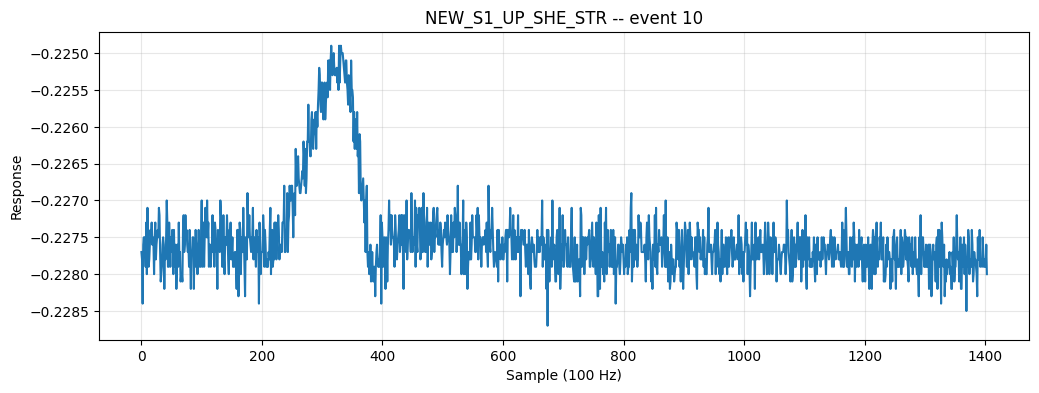

In [7]:
from aquinas_toolkit import AquinasReader, plot_waveform, plot_sensor_grid, plot_sensor_overlay
from aquinas_toolkit.utils import find_dataset_root

dataset_root = find_dataset_root()
dataset_dir = dataset_root / "AQUINAS_SET1_2022_07"
reader = AquinasReader(dataset_dir)

print(f"Dataset: {reader.set_name}")
print(f"\nSensor summary ({len(reader.table_files)} sensors):")
reader.summary()

sensors = reader.list_sensor_names()
print(f"Total sensors: {len(sensors)}")

# Choose a sensor and event index
sensor = sensors[10]
event_idx = 10

index_df = reader.load_index_table(sensor)
meta, waveform = reader.read_record(sensor_name=sensor, row_index=event_idx)

meta, waveform = reader.read_record(sensor, row_index=event_idx)
plot_waveform(waveform, title=f"{sensor} -- event {event_idx}")

## Retained Sample Preview

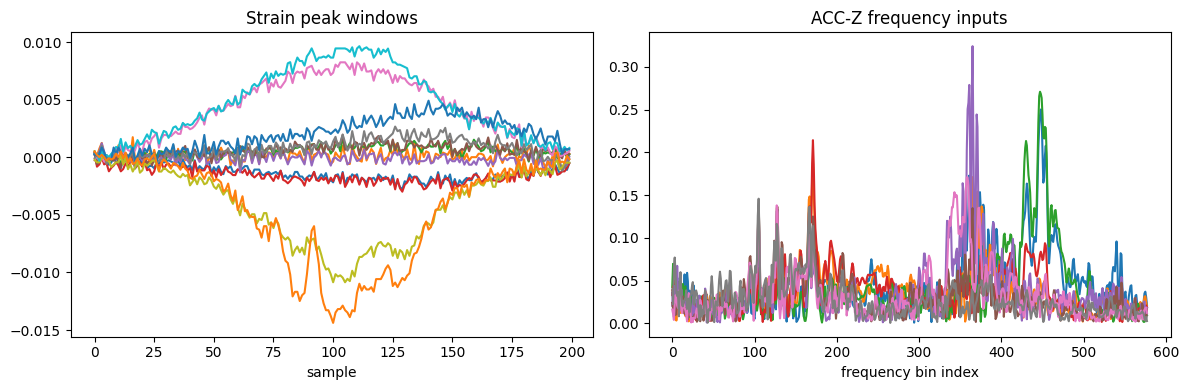

In [27]:
if len(neural_inputs):
    sample = neural_inputs[0]
    strain_slice = input_slices["strain"]
    acc_slice = input_slices["acc_z_frequency"]
    strain_block = sample[strain_slice["start"] : strain_slice["stop"]].reshape(strain_slice["shape"])
    acc_block = sample[acc_slice["start"] : acc_slice["stop"]].reshape(acc_slice["shape"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(strain_block)
    axes[0].set_title("Strain peak windows")
    axes[0].set_xlabel("sample")
    axes[1].plot(acc_block)
    axes[1].set_title("ACC-Z frequency inputs")
    axes[1].set_xlabel("frequency bin index")
    fig.tight_layout()
else:
    print("No retained neural samples in this run.")

## Flagged Plot Files

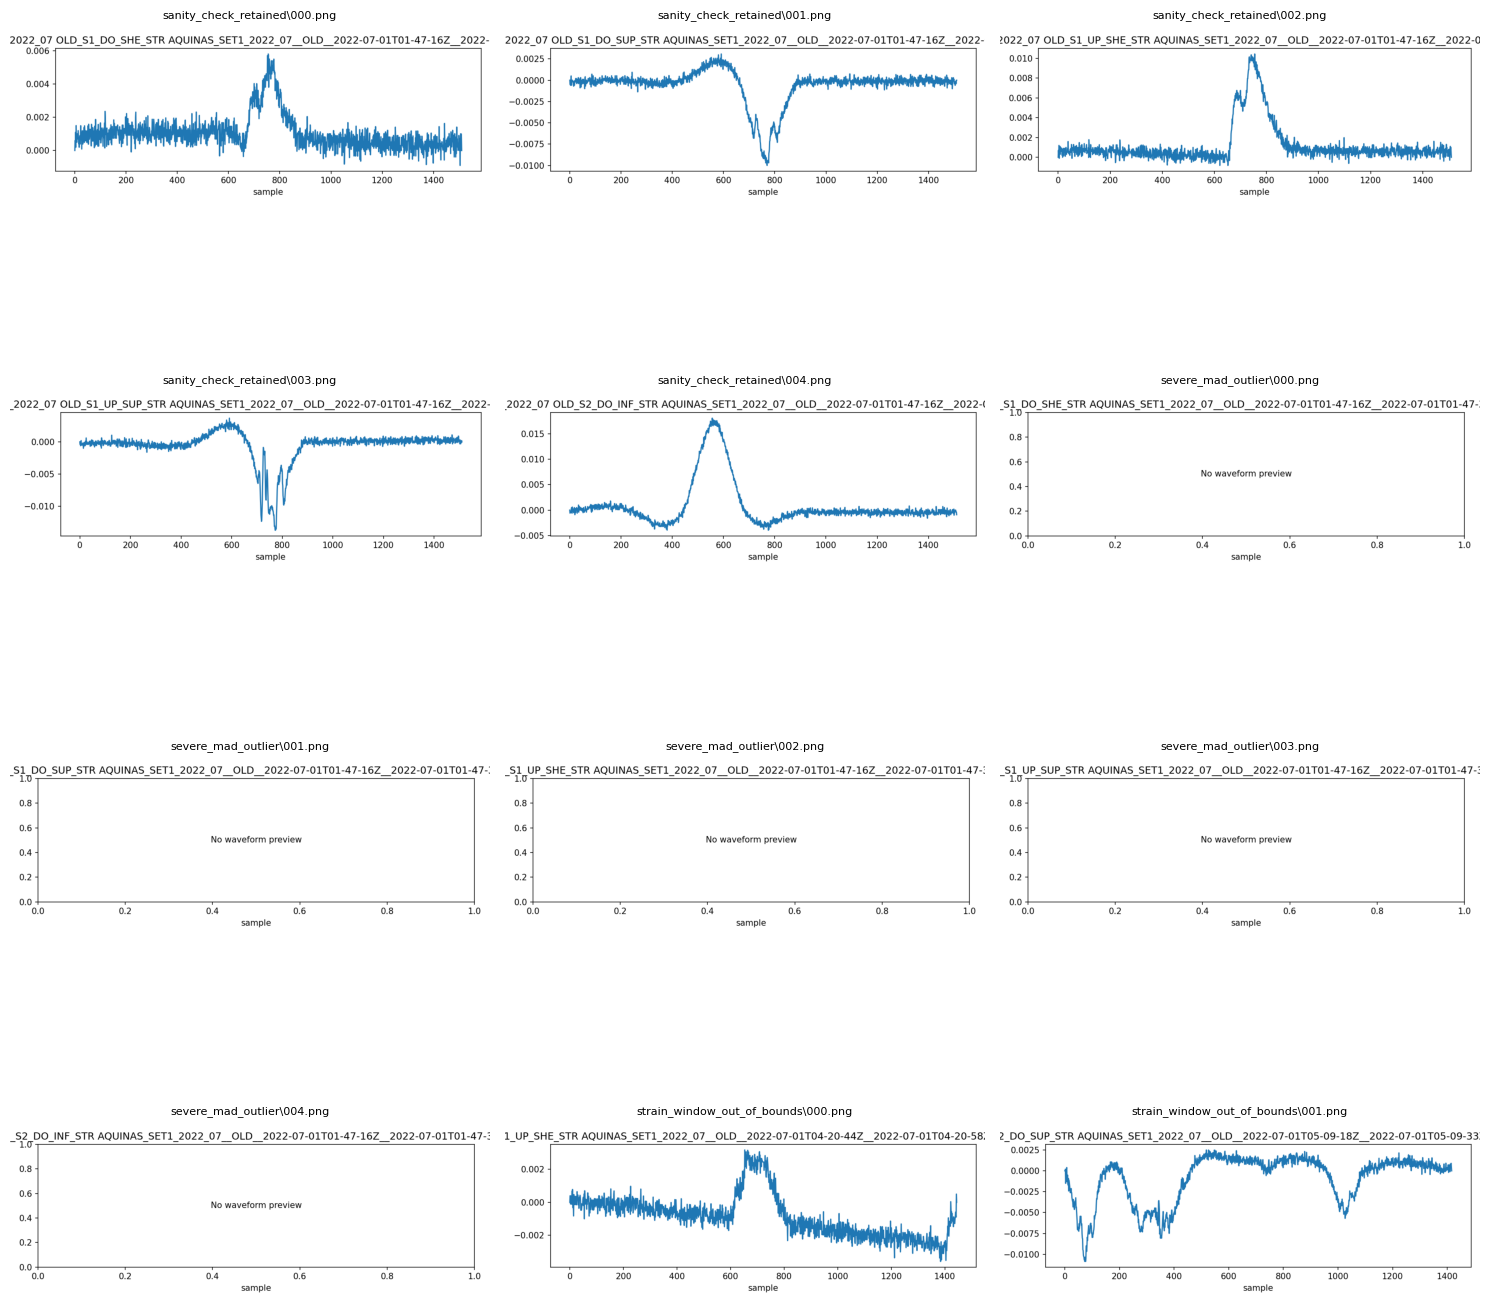

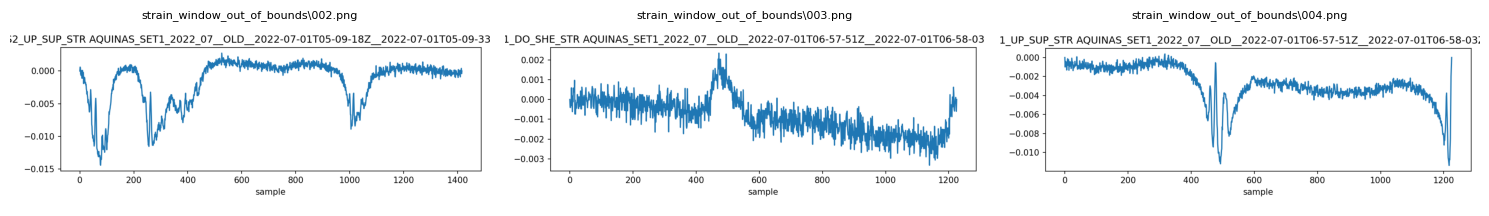

In [28]:
flagged_root = qc_dir / "flagged_plots"
plot_files = sorted(path for path in flagged_root.rglob("*.png"))
pd.DataFrame({"plot": [str(path.relative_to(flagged_root)) for path in plot_files[:50]]})

if not plot_files:
    print(f"No PNG files found under: {flagged_root}")
else:
    ncols = 3
    batch_size = 12

    for start in range(0, len(plot_files), batch_size):
        batch = plot_files[start : start + batch_size]
        nrows = int(np.ceil(len(batch) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
        axes = np.atleast_1d(axes).ravel()

        for ax, path in zip(axes, batch):
            ax.imshow(plt.imread(path))
            ax.set_title(str(path.relative_to(flagged_root)), fontsize=8)
            ax.axis("off")

        for ax in axes[len(batch):]:
            ax.axis("off")

        fig.tight_layout()
        plt.show()